In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
orders = pd.read_csv("datasets/olist_orders_dataset.csv")
payments = pd.read_csv("datasets/olist_order_payments_dataset.csv")
customers = pd.read_csv("datasets/olist_customers_dataset.csv")

In [16]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [17]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [18]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [19]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

In [20]:
orders["order_year"] = orders["order_purchase_timestamp"].dt.year
orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M")

In [21]:
df = orders.merge(payments, on="order_id", how="left")

In [22]:
df = df.merge(customers, on="customer_id", how="left")

In [23]:
monthly_revenue = (df.groupby("order_month")["payment_value"].sum().reset_index())

In [24]:
monthly_revenue.head()

,order_month,payment_value
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01


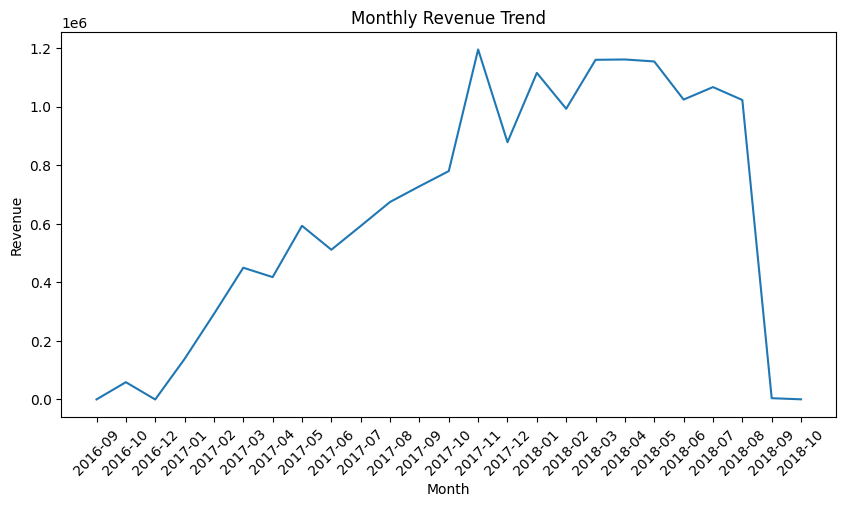

In [25]:
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue["order_month"].astype(str),
         monthly_revenue["payment_value"])

plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [26]:
monthly_revenue["rolling_3m"] = (monthly_revenue["payment_value"].rolling(window=3).mean())

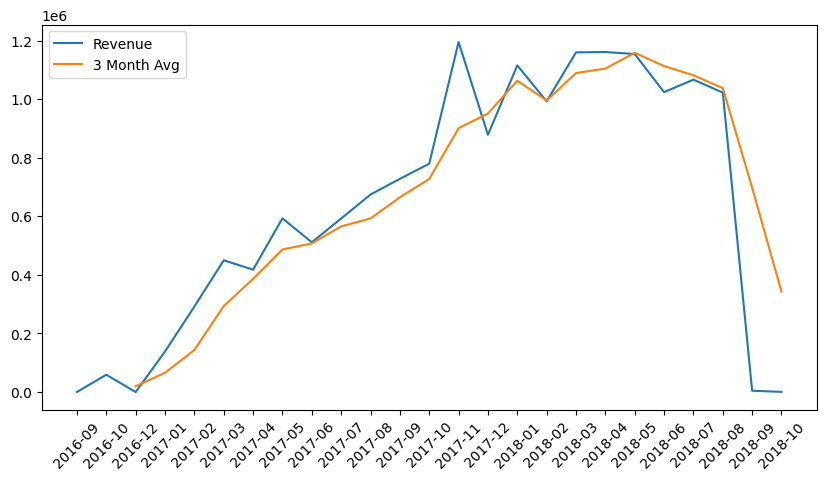

In [27]:
plt.figure(figsize=(10,5))

plt.plot(monthly_revenue["order_month"].astype(str),
         monthly_revenue["payment_value"],
         label="Revenue")

plt.plot(monthly_revenue["order_month"].astype(str),
         monthly_revenue["rolling_3m"],
         label="3 Month Avg")

plt.legend()
plt.xticks(rotation=45)

plt.show()